# Fashion Recommendation Prototype

## 1. Objective

The objective of this notebook is to build a first recommendation prototype using the previously trained style and clothing type classifiers.

The prototype takes an input clothing image and predicts:

- the style of the item
- the clothing type of the item

These predictions are then used to retrieve compatible items from the dataset.

The first version of the recommendation system uses a simple rule-based approach:

- recommend items with the same predicted style
- exclude items with the same predicted clothing type

For example, if the input image is predicted as a gothic jacket, the system should recommend gothic items that are not jackets, such as gothic pants, gothic shoes, or gothic tshirts.

This notebook does not attempt to solve full outfit compatibility yet. Instead, it creates a practical first prototype that connects the classification models to a simple retrieval-based recommendation system.

## 2. Project Context

The previous notebooks developed two baseline models. The first model predicts fashion style, while the second model predicts clothing type.

The style classifier provides information about the visual identity of the item, such as whether it belongs to formal, gothic, sporty, or streetwear fashion. The clothing type classifier identifies the functional category of the item, such as jacket, pants, shoes, or tshirt.

Combining these two predictions makes it possible to build a simple recommendation system. Instead of recommending random items, the system can retrieve items that match the predicted style while avoiding items of the same type.

This approach is intentionally simple. It does not yet use visual embeddings, user preferences, or learned outfit compatibility. However, it is useful as a first prototype because it shows how the trained models can be used in a functional recommendation workflow.

## 3. Recommendation Logic

The recommendation logic in this notebook is based on two predicted labels:

- predicted style
- predicted clothing type

The system follows this rule:

```text
Recommend items where:
    item style = predicted style
    item type != predicted type
```

This means that the system keeps the style consistent while recommending different clothing categories.

For example:
```text
Input image:
    predicted style = gothic
    predicted type = jacket

Recommended items:
    gothic pants
    gothic shoes
    gothic tshirts
```

This creates a basic outfit-building logic where the recommended items are stylistically related but functionally different from the input item.

## 4. Import Libraries

The notebook uses `PyTorch` and torchvision to load the trained models and process input images. It also uses pandas and matplotlib to manage metadata and visualize recommendations.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: CUDA


## 5. Load Trained Models

The recommendation prototype uses the two previously trained baseline models:

- the style classifier
- the clothing type classifier

Both models use the same `ResNet34` architecture, but each model has a different final classification layer depending on the target labels. The saved checkpoints also include the class names, which are needed to convert model outputs into readable predictions.

In [2]:
style_model_path = "../models/style_resnet34.pth"
type_model_path = "../models/type_resnet34.pth"

style_checkpoint = torch.load(style_model_path, map_location=device)
type_checkpoint = torch.load(type_model_path, map_location=device)

style_class_names = style_checkpoint["class_names"]
type_class_names = type_checkpoint["class_names"]

print("Style classes:", style_class_names)
print("Type classes:", type_class_names)

Style classes: ['formal', 'gothic', 'sporty', 'streetwear']
Type classes: ['jacket', 'pants', 'shoes', 'tshirt']


In [3]:
def load_resnet34_classifier(checkpoint, num_classes):
  model = models.resnet34(weights=None)
  in_features = model.fc.in_features
  model.fc = nn.Linear(in_features, num_classes)
  model.load_state_dict(checkpoint["model_state_dict"])
  model = model.to(device)
  model.eval()
  return model

style_model = load_resnet34_classifier(style_checkpoint, len(style_class_names))
type_model = load_resnet34_classifier(type_checkpoint, len(type_class_names))

print("Both models loaded successfully.")

Both models loaded successfully.


## 6. Prediction Pipeline

### 6.1. Image Transform

Before an image can be passed into the trained models, it must be processed in the same way as during training and evaluation.

The image is resized to 224 by 224 pixels, converted into a tensor, and normalized using ImageNet statistics.

In [4]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 6.2. Prediction Function

A helper function is defined to run inference using both the style and clothing type classifiers.

The function returns:

- predicted style
- predicted clothing type
- confidence score for each prediction

In [5]:
def predict_style_and_type(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        style_outputs = style_model(input_tensor)
        type_outputs = type_model(input_tensor)

        style_probs = torch.softmax(style_outputs, dim=1)
        type_probs = torch.softmax(type_outputs, dim=1)

        style_pred_idx = torch.argmax(style_probs, dim=1).item()
        type_pred_idx = torch.argmax(type_probs, dim=1).item()

        predicted_style = style_class_names[style_pred_idx]
        predicted_type = type_class_names[type_pred_idx]

        style_confidence = style_probs[0][style_pred_idx].item()
        type_confidence = type_probs[0][type_pred_idx].item()

    return {
        "style": predicted_style,
        "type": predicted_type,
        "style_confidence": style_confidence,
        "type_confidence": type_confidence
    }

### 6.3. Example Prediction

To verify that both models work correctly, a test image is passed through the prediction function.

In [9]:
test_image_path = "../dataset/cleaned/gothic/jacket/gothic_jacket_025.png"

prediction = predict_style_and_type(test_image_path)
prediction

{'style': 'gothic',
 'type': 'jacket',
 'style_confidence': 0.9474146366119385,
 'type_confidence': 0.8012428283691406}

## 7. Build Recommendation Catalogue

The recommendation system needs a catalogue of available items that it can retrieve from.

For this first prototype, the catalogue is built from the cleaned dataset folder. Each image path is stored together with its known style and clothing type. This allows the recommendation function to filter items based on the predicted style and predicted clothing type of the input image.

### 7.1. Create Catalogue from Cleaned Dataset

In [11]:
catalogue_root = "../dataset/cleaned"

catalogue_items = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = os.path.join(catalogue_root, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = os.path.join(type_path, filename)

            if os.path.isfile(image_path):
                catalogue_items.append({
                    "image_path": image_path,
                    "style": style,
                    "type": item_type,
                    "filename": filename
                })

catalogue_df = pd.DataFrame(catalogue_items)

print("Catalogue size:", len(catalogue_df))
# catalogue_df.head()

Catalogue size: 800


### 7.2. Check Catalogue Distribution

Before using the catalogue for recommendations, the distribution of styles and clothing types is checked to confirm that the retrieval pool is balanced.

In [12]:
catalogue_distribution = pd.crosstab(catalogue_df["style"], catalogue_df["type"])
catalogue_distribution

type,jacket,pants,shoes,tshirt
style,,,,
formal,50,50,50,50
gothic,50,50,50,50
sporty,50,50,50,50
streetwear,50,50,50,50


## 8. Recommendation Function

The recommendation function combines the prediction pipeline with the catalogue.

First, the input image is passed through the style and clothing type classifiers. Then, the catalogue is filtered using the following rule:

- keep items with the same predicted style
- remove items with the same predicted clothing type

This creates a simple first recommendation system where suggested items match the input style but belong to different clothing categories.

### 8.1 Filter Catalogue by Predicted Labels

In [17]:
def recommend_outfit_items(image_path, catalogue_df):
    prediction = predict_style_and_type(image_path)

    predicted_style = prediction["style"]
    predicted_type = prediction["type"]

    candidates = catalogue_df[
        (catalogue_df["style"] == predicted_style) &
        (catalogue_df["type"] != predicted_type)
    ].copy()

    recommended_rows = []

    for item_type in sorted(candidates["type"].unique()):
        type_candidates = candidates[candidates["type"] == item_type]

        if len(type_candidates) > 0:
            selected_item = type_candidates.sample(n=1, random_state=42)
            recommended_rows.append(selected_item)

    if len(recommended_rows) == 0:
        recommendations = pd.DataFrame(columns=catalogue_df.columns)
    else:
        recommendations = pd.concat(recommended_rows)

    return prediction, recommendations

### 8.2 Test Recommendation Function

The recommendation function is tested using one example input image from the dataset.

In [18]:
test_image_path = "../dataset/cleaned/gothic/jacket/gothic_jacket_025.png"

prediction, recommendations = recommend_outfit_items(
    test_image_path,
    catalogue_df
)

print("Prediction:")
print(prediction)

recommendations

recommendations

Prediction:
{'style': 'gothic', 'type': 'jacket', 'style_confidence': 0.9474146366119385, 'type_confidence': 0.8012428283691406}


,image_path,style,type,filename
263,../dataset/cleaned\gothic\pants\gothic_pants_0...,gothic,pants,gothic_pants_014.png
313,../dataset/cleaned\gothic\shoes\gothic_shoes_0...,gothic,shoes,gothic_shoes_014.png
363,../dataset/cleaned\gothic\tshirt\gothic_tshirt...,gothic,tshirt,gothic_tshirt_014.png


## 9. Visualize Recommendations

Since this prototype recommends clothing images, visual inspection is important. The following function displays the input image together with the recommended items.

This makes it easier to check whether the recommendations follow the expected rule: same style, different clothing type.

In [19]:
def show_recommendations(input_image_path, prediction, recommendations):
    total_images = 1 + len(recommendations)
    cols = min(total_images, 4)
    rows = int(np.ceil(total_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    # Show input image
    input_image = Image.open(input_image_path).convert("RGB")
    axes[0].imshow(input_image)
    axes[0].set_title(
        f"Input\nStyle: {prediction['style']} ({prediction['style_confidence']:.2f})\n"
        f"Type: {prediction['type']} ({prediction['type_confidence']:.2f})"
    )
    axes[0].axis("off")

    # Show recommendations
    for i, (_, row) in enumerate(recommendations.iterrows(), start=1):
        image = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(image)
        axes[i].set_title(f"Recommended\n{row['style']} {row['type']}")
        axes[i].axis("off")

    # Hide unused axes
    for j in range(total_images, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

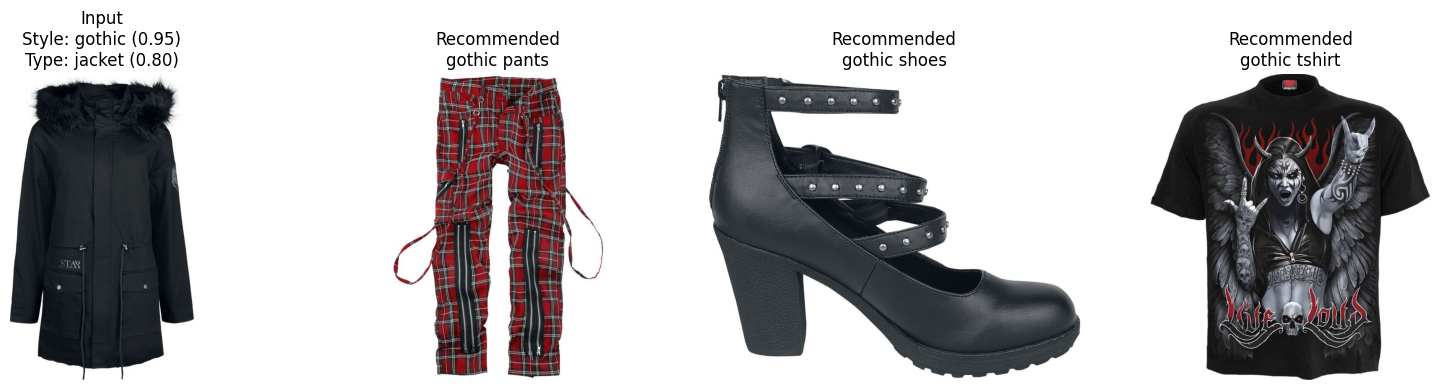

In [20]:
show_recommendations(test_image_path, prediction, recommendations)

## 10. Results Interpretation

The recommendation prototype combines the outputs of the style classifier and the clothing type classifier to generate simple outfit suggestions.

Given an input item, the system:

- predicts the style of the item
- predicts the clothing type of the item
- retrieves items from the dataset with the same style
- excludes items with the same clothing type
- selects one item per remaining clothing category

This results in a basic outfit suggestion composed of complementary items.

### 10.1. Observations

The system produces visually consistent recommendations. For example, when given a gothic jacket, the recommended items are:

- gothic pants
- gothic shoes
- gothic tshirt

This shows that:

- the style classifier provides a coherent grouping signal
- the clothing type classifier correctly separates item categories
- combining both predictions produces meaningful retrieval behavior

### 10.2. Limitations

This recommendation approach is still very simple:

- recommendations are randomly sampled within each category
- there is no ranking based on similarity, color, or fit
- the system does not consider compatibility beyond style matching
- no personalization is included

Despite these limitations, the prototype demonstrates that combining classification outputs can already produce structured and usable outfit suggestions.

## 11. Conclusion

This notebook introduced a first recommendation prototype based on the outputs of two classification models.

By combining:

- style prediction
- clothing type prediction

the system is able to generate simple outfit suggestions from a dataset of fashion items.

The results show that even a basic rule-based retrieval system can produce coherent recommendations when built on top of reliable classification models.

This confirms that the chosen project direction is viable and that classification outputs can serve as a strong foundation for more advanced recommendation systems.

## 12. Next Steps

The next stage of the project will focus on improving the recommendation system.

Possible improvements include:

- ranking recommendations using visual similarity instead of random sampling
- incorporating color and texture features
- allowing multiple recommendations per category
- filtering recommendations based on user preferences
- exploring embedding-based retrieval instead of rule-based filtering

These improvements will move the system from a simple prototype toward a more realistic and intelligent fashion recommendation engine.

## 13. Saving the results

### 13.1. Saving the example output

In [21]:
recommendation_summary = {
    "experiment": "rule_based_recommendation_baseline",
    "input_image": test_image_path,
    "predicted_style": prediction["style"],
    "predicted_type": prediction["type"],
    "style_confidence": prediction["style_confidence"],
    "type_confidence": prediction["type_confidence"],
    "recommendation_rule": "same predicted style, different clothing type, one item per missing type",
    "num_recommendations": len(recommendations)
}

pd.DataFrame([recommendation_summary]).to_csv(
    "../results/recommendation_baseline/recommendation_summary.csv",
    index=False
)

### 13.2. Saving the recommended items

In [22]:
recommendations.to_csv(
    "../results/recommendation_baseline/recommended_items_example.csv",
    index=False
)

### 13.3. Saving the catalogue distribution

In [23]:
catalogue_distribution.to_csv(
    "../results/recommendation_baseline/catalogue_distribution.csv"
)